# 10k Occupancy Investigation

Investigate why there is a drop in counts in S-phase. Is this a modeling/numerical issue?


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [14]:
from src.GenomeDeconvolution import GenomeDeconvolution
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

chrom = 3
genome_deconvolution = GenomeDeconvolution(save_dir=None)
genome_deconvolution.load_chrom_span(chrom, (100000, 105000), log=False)


In [15]:
adapted_G = genome_deconvolution.combined_model.G.copy()

In [16]:
offset = 0
genome_deconvolution.combined_model.deconvolve(G=adapted_G+offset)

Deconvolving combined model with gamma=0.0066
Deconvolving bin size: 10x10
of G shape: (31, 13000)
Deconvolving with gamma=0.0066
0/13000 - 00:00:00.104
500/13000 - 00:00:43.722
1000/13000 - 00:01:26.124
1500/13000 - 00:02:07.713
2000/13000 - 00:02:48.856
2500/13000 - 00:03:26.486
3000/13000 - 00:04:02.992
3500/13000 - 00:04:39.930
4000/13000 - 00:05:16.370
4500/13000 - 00:05:55.911
5000/13000 - 00:06:34.467
5500/13000 - 00:07:12.651
6000/13000 - 00:07:50.629
6500/13000 - 00:08:28.333
7000/13000 - 00:09:06.547
7500/13000 - 00:09:42.725
8000/13000 - 00:10:19.597
8500/13000 - 00:10:55.927
9000/13000 - 00:11:32.673
9500/13000 - 00:12:09.547
10000/13000 - 00:12:45.960
10500/13000 - 00:13:22.605
11000/13000 - 00:13:59.087
11500/13000 - 00:14:35.851
12000/13000 - 00:15:12.167
12500/13000 - 00:15:48.602
Deconvolved in : 00:16:27.660
The fitting norm is 13.38, the smoothing norm is: 3.32


In [17]:
# Debug the drop off from G1 to S, can we identify the reasoning? Is it numerical?
# Is it resolvable?

f = genome_deconvolution.combined_model.deconvolved_f_value.copy()

In [18]:
from src.config import load_configs_by_config_type
config, _ = load_configs_by_config_type('shared')
t_indices = config.get_Hpositions_for_branch('t')
s_indices = config.get_Hpositions_for_phase('S')

In [19]:
combined_model = genome_deconvolution.combined_model

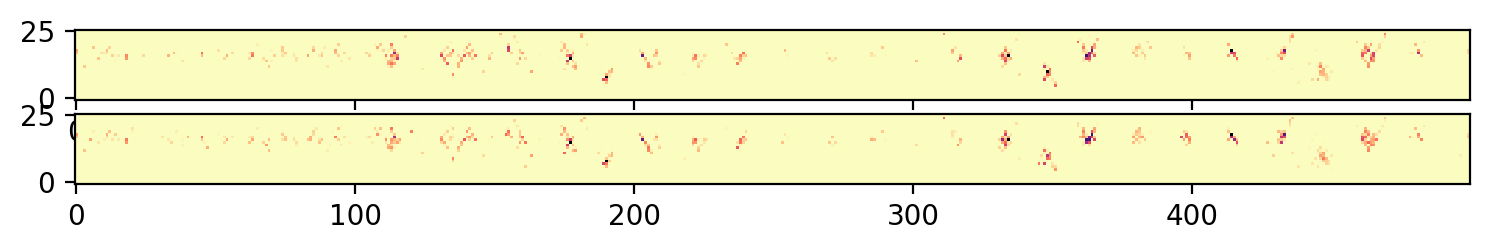

In [20]:

plt.figure(figsize=(9, 1))
plt.subplot(2, 1, 1)
plt.imshow(f[t_indices[s_indices[0]-5], :].reshape(combined_model.chrom1_model.image_shape), cmap='magma_r', 
           origin='lower', interpolation='none', vmin=offset, vmax=30, aspect='auto')

plt.subplot(2, 1, 2)
plt.imshow(f[t_indices[s_indices[-1]], :].reshape(combined_model.chrom1_model.image_shape), cmap='magma_r', 
           origin='lower', interpolation='none', vmin=offset, vmax=30, aspect='auto')

0

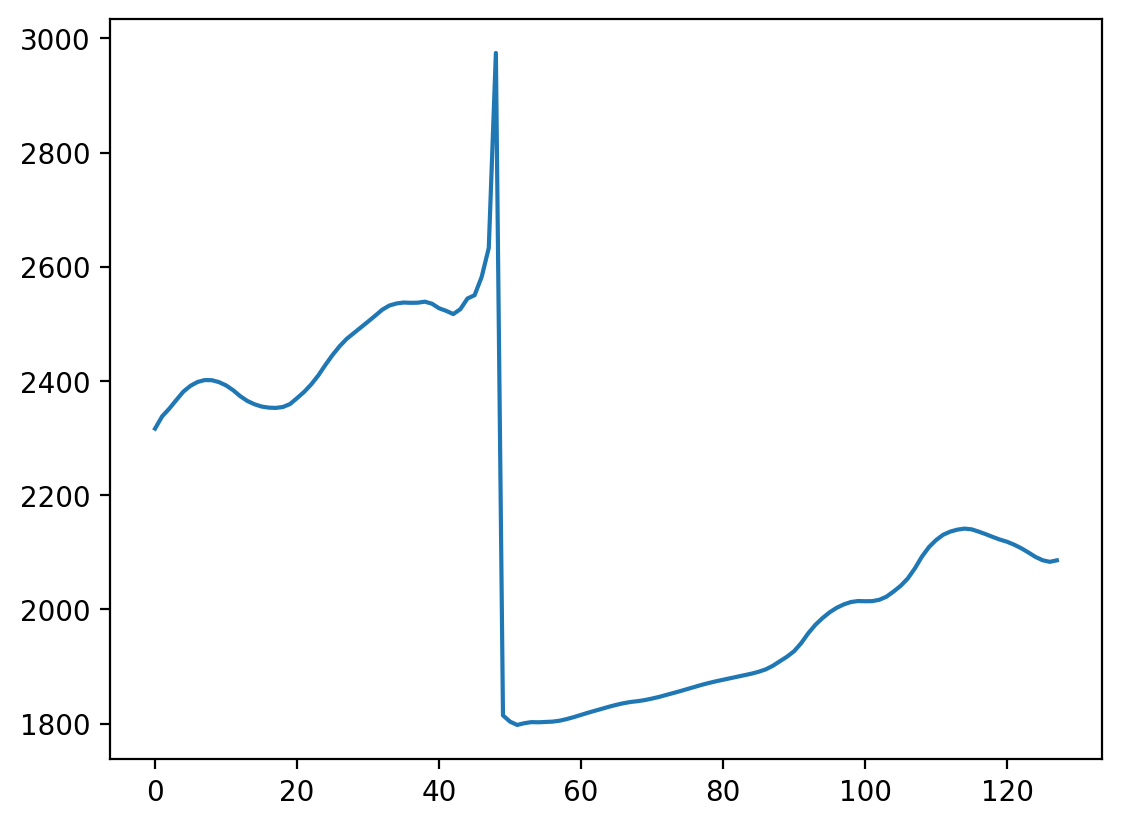

In [21]:
plt.plot(f[t_indices, :].sum(axis=1))

0

0

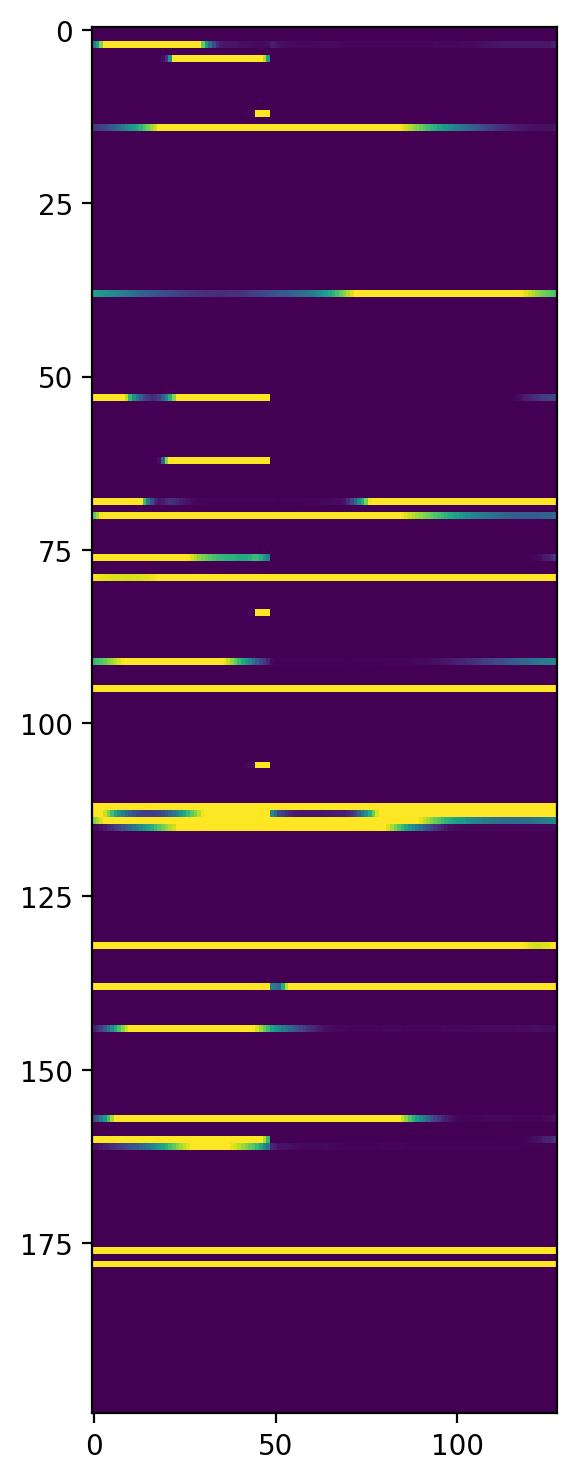

In [23]:
plt.figure(figsize=(3, 9))
plt.imshow(f[t_indices, 7000:7200].T, aspect='auto', vmax=1, vmin=0)

0